## Demo: Exploring Public APIs with Python

This notebook demonstrates how public APIs work, how to access them using Python, and what kind of data they return.

#### Key Topics:
- Learn how to make API requests with `requests`
- Inspect and parse JSON responses
- Convert API data into pandas DataFrames
- Explore how API data can support cleaning, categorization, aggregation, and feature engineering

#### Notes on Structure of API Data:
- Top level -> dictionary
- "data" -> list
- each item -> nested dictionary
- actual value -> buried in "attributes"

#### Data source for this demo:
- Public API Lists: a curated catalog of free public APIs (https://github.com/public-api-lists/public-api-lists)

The README is organized by subject, with an index at the top. Each subject contains a table listing the API, Description, Auth, HTTPS, and CORS.

- API: Typically a link to the API's documentation page. The documentation page explains available endpoints, required parameters, authentication, and example requests/responses
- Description: self explanatory
- Auth: A value of 'No' indicates that no authentication is required. A value of 'apiKey' inidcates you must sign up and include a key in requests. A value of 'OAuth' indicates a more complex login flow.
- HTTPS: indicates if the API is secure or not (HTTPS vs HTTP)
- CORS: Cross-Origin Resource Sharing. This controls whether a browser is allowed to call an API from a different website. For the purposes of this notebook, we do not have to consider CORS, but if calling an API from a Frontend such as JavaScript in a browser, a 'No' in the CORS column indicates that browser requests will be blocked.

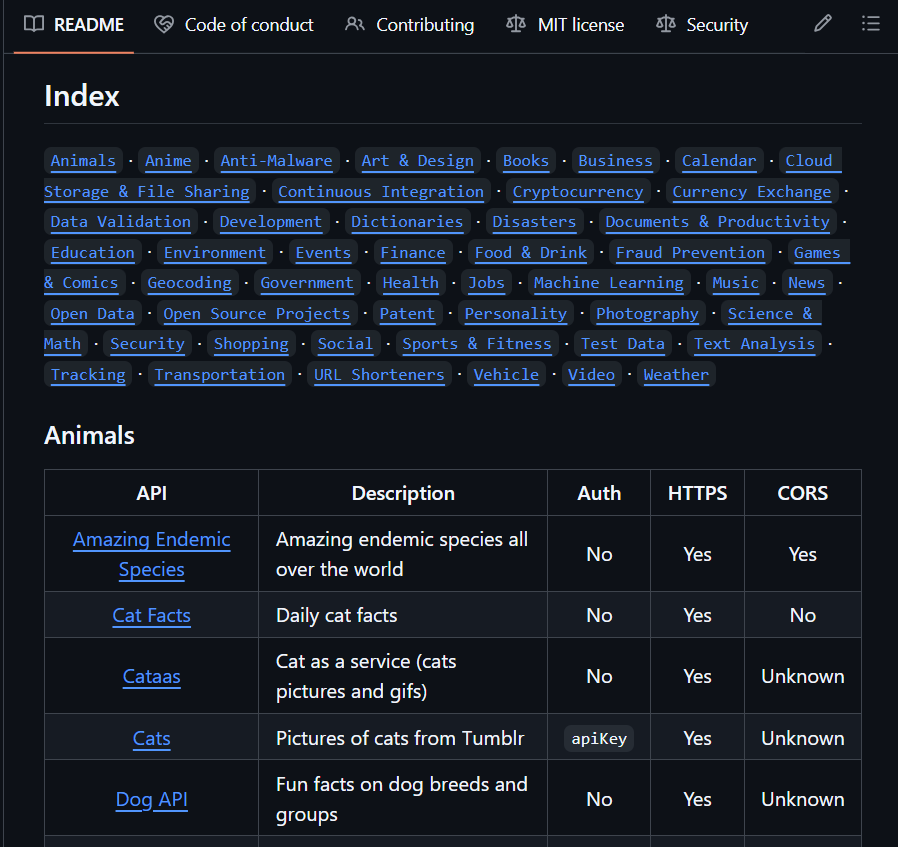



---

### Demo 1: Auth=No, HTTPS=Yes

For the first demo, we will select an API with the easiest parameters to work with. We'll look at Dog API. "Powered by Stratonauts Dog API".

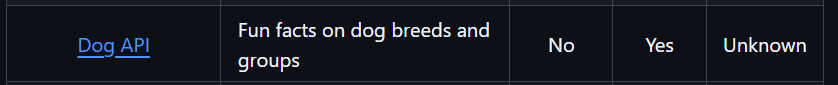

#### Steps:
1. Visit the documentation site linked (https://dogapi.dog/)
2. Read through documentation: Overview, Terms of Use, Demo, and API Docs.
3. Obtain the actual API: https://dogapi.dog/docs/api-v2
4. Call the public API
5. Inspect the raw JSON
6. Extract useful fields
7. Structure the data for analysis


In [3]:
## Begin the Demo
import requests
url = "https://dogapi.dog/api/v2/breeds"
response = requests.get(url, timeout=10)
print("Status code: ", response.status_code)  # Print the HTTP status code
print("Content type: ", response.headers.get('Content-Type'))  # Print the content type of the response
print("Raw text preview: ", response.text[:200])  # Print a preview of the raw text

data = response.json()

Status code:  200
Content type:  application/vnd.api+json; charset=utf-8
Raw text preview:  {"data":[{"id":"036feed0-da8a-42c9-ab9a-57449b530b13","type":"breed","attributes":{"name":"Affenpinscher","description":"The Affenpinscher is a small and playful breed of dog that was originally bred 


In [4]:
## Now inspect the data structure
print("Type of data: ", type(data))  # Print the type of the data
print("Keys in the data: ", data.keys())  # Print the keys in the data
print("Number of breeds: ", len(data['data']))  # Print the number of breeds
print("First breed entry: ", data['data'][0])  # Print the first breed entry
print("Keys of the first breed entry: ", data['data'][0].keys())  # Print the keys of the first breed entry
print("Attributes of the first breed entry: ", data['data'][0]['attributes'].keys())  # Print the attributes of the first breed entry
print("Name of the first breed: ", data['data'][0]['attributes']['name'])  # Print the name of the first breed


Type of data:  <class 'dict'>
Keys in the data:  dict_keys(['data', 'meta', 'links'])
Number of breeds:  283
First breed entry:  {'id': '036feed0-da8a-42c9-ab9a-57449b530b13', 'type': 'breed', 'attributes': {'name': 'Affenpinscher', 'description': 'The Affenpinscher is a small and playful breed of dog that was originally bred in Germany for hunting small game. They are intelligent, energetic, and affectionate, and make excellent companion dogs.', 'life': {'max': 16, 'min': 14}, 'male_weight': {'max': 5, 'min': 3}, 'female_weight': {'max': 5, 'min': 3}, 'hypoallergenic': True}, 'relationships': {'group': {'data': {'id': 'f56dc4b1-ba1a-4454-8ce2-bd5d41404a0c', 'type': 'group'}}}}
Keys of the first breed entry:  dict_keys(['id', 'type', 'attributes', 'relationships'])
Attributes of the first breed entry:  dict_keys(['name', 'description', 'life', 'male_weight', 'female_weight', 'hypoallergenic'])
Name of the first breed:  Affenpinscher


### What the above output tells us
Top level:
- data- actual breed records
- meta- metadata about the response
- links- pagination or nav links

Each breed record contains:
- id- unique identifier
- type- record type (breed in this dataset)
- attributes- the main breed features
- relationships- linked related objects (breed group in this dataset)

Attributes of breed types:
- name
- description
- life
- male_weight
- female_weight
- hypoallergenic

Next, we will create a dataframe for the Dog Breed data

In [5]:
import pandas as pd
breeds_df = pd.json_normalize(data['data'])
print("Head of breeds DataFrame: ")
print(breeds_df.head())

Head of breeds DataFrame: 
                                     id   type   attributes.name  \
0  036feed0-da8a-42c9-ab9a-57449b530b13  breed     Affenpinscher   
1  dd9362cc-52e0-462d-b856-fccdcf24b140  breed      Afghan Hound   
2  1460844f-841c-4de8-b788-271aa4d63224  breed  Airedale Terrier   
3  e7e99424-d514-4b56-9f0c-05736f6dd22d  breed             Akita   
4  667c7359-a739-4f2b-abb4-98867671e375  breed  Alaskan Klee Kai   

                              attributes.description  attributes.life.max  \
0  The Affenpinscher is a small and playful breed...                   16   
1  The Afghan Hound is a large and elegant breed ...                   14   
2  The Airedale Terrier is a large and powerful b...                   14   
3  The Akita is a large, muscular dog breed that ...                   12   
4  The Alaskan Klee Kai is a small to medium-size...                   15   

   attributes.life.min  attributes.male_weight.max  \
0                   14                         

In [6]:
breeds_df.columns.tolist() # Print the list of column names in the DataFrame

['id',
 'type',
 'attributes.name',
 'attributes.description',
 'attributes.life.max',
 'attributes.life.min',
 'attributes.male_weight.max',
 'attributes.male_weight.min',
 'attributes.female_weight.max',
 'attributes.female_weight.min',
 'attributes.hypoallergenic',
 'relationships.group.data.id',
 'relationships.group.data.type']

In [8]:
## Clean up column names by removing the 'attributes.' prefix:
breeds_df.columns = breeds_df.columns.str.replace('attributes.', '', regex=False)
print("Cleaned column names: \n", breeds_df.columns.tolist())  # Print the cleaned list

Cleaned column names: 
 ['id', 'type', 'name', 'description', 'life.max', 'life.min', 'male_weight.max', 'male_weight.min', 'female_weight.max', 'female_weight.min', 'hypoallergenic', 'relationships.group.data.id', 'relationships.group.data.type']


### Next Steps: feature engineering and analysis

We'll create a couple of calculated columns and display a graph to illustrate ability to work with the data now.

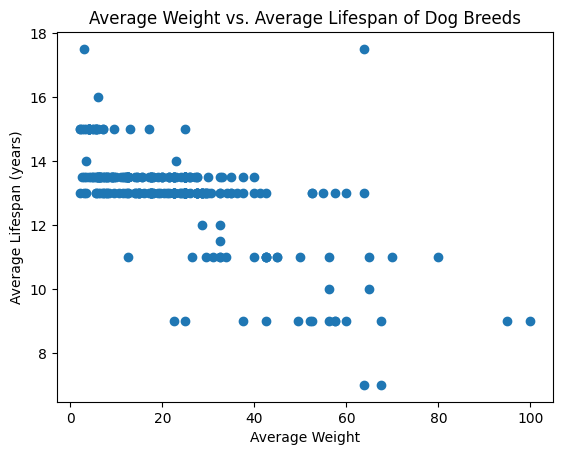

In [12]:
## Add an average weight column for each breed:
breeds_df['weight_avg'] = (
    breeds_df['male_weight.min'] +
    breeds_df['male_weight.max'] +
    breeds_df['female_weight.min'] +
    breeds_df['female_weight.max']
) / 4

## Add an average lifespan column for each breed:
breeds_df['lifespan_avg'] = (
    breeds_df['life.min'] +
    breeds_df['life.max']
) / 2

## import plot library
import matplotlib.pyplot as plt

## Plot average weight vs. average lifespan
plt.figure()
plt.scatter(breeds_df['weight_avg'], breeds_df['lifespan_avg'])
plt.title('Average Weight vs. Average Lifespan of Dog Breeds')
plt.xlabel('Average Weight')
plt.ylabel('Average Lifespan (years)')
plt.show()

Now let's improve the graph by coloring the datapoints by work group, adding a legend, and jittering the points so they are not right on top of each other.

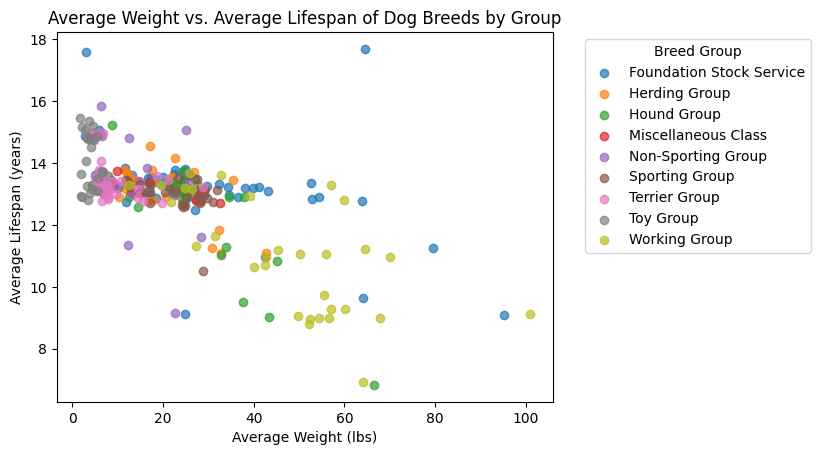

In [15]:
import numpy as np

## Fetch the breed group data to get the group names
breed_group_url = "https://dogapi.dog/api/v2/groups"
breed_group_response = requests.get(breed_group_url, timeout=10)
breed_group_data = breed_group_response.json()

## Create a mapping of group IDs to group names
group_map = {
    g["id"]: g["attributes"]["name"] for g in breed_group_data['data']
}

## Add a column for breed group names
breeds_df['breed_group_name'] = breeds_df['relationships.group.data.id'].map(group_map)

## Plot average weight vs. average lifespan, colored by breed group and with jittering to reduce overlap
plt.figure()
for group, subset in breeds_df.groupby('breed_group_name'):
    plt.scatter(
        subset['weight_avg'] + np.random.normal(0,0.5, size=len(subset)),  # Add jitter to weight
        subset['lifespan_avg'] + np.random.normal(0,0.2, size=len(subset)),  # Add jitter to lifespan
        label=group, 
        alpha=0.7
    )
plt.xlabel('Average Weight (lbs)')
plt.ylabel('Average Lifespan (years)')
plt.title('Average Weight vs. Average Lifespan of Dog Breeds by Group')
plt.legend(title='Breed Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### Demo 1 Wrap Up:

Advantages of APIs for data access:
- Real-time or up-to-date data
    - APIs provide current data directly from the source
    - No need to manually download updated files
- Automated data retrieval
    - Data can be accessed via script or code
    - enables repeatable and scalable workflows
- Structured data formats (JSON)
    - Data is already organized in a machine-readable format
    - Data is easier to parse compared to raw text or scraped HTML
- Flexibility and filtering
    - Many APIs allow parameters to control what data is returned
    - Reduces the need for heavy post-processing
- Integration with data pipelines
    - APIs can feed directly into analysis, dashboards, or models
    - Common in real-world data engineering workflows


### Demo 2: Auth= apiKey, HTTPS=Yes*

Now we will demonstrate more advanced API usage by working with an API that requires authentication and supports query parameters. We will look at WeatherStack(https://weatherstack.com/documentation)

Steps:
1. Sign up for free access to obtain API key 
2. Get the weatherstack endpoint: http://api.weatherstack.com/current (*http is the only option for free usage)
3. Make the API request, including query parameters
4. Inspect the response structure
5. Extract useful features and convert to dataframe



In [ ]:
import requests
import os
from dotenv import load_dotenv
load_dotenv()  # Load environment variables from .env file (API KEY)
## API keys are stored in environment variables using a `.env` file to avoid exposing sensitive information in code.
weather_api_key = os.getenv('MY_WEATHER_API_KEY')

url = "http://api.weatherstack.com/current"

params = {
    'access_key': weather_api_key,
    'query': 'Denver'
}

response = requests.get(url, params=params, timeout=10)
weather_data = response.json()


In [24]:
## explore the weather data structure
print("Type:", type(weather_data))
print("Keys:", weather_data.keys())

## explore the sections of the weather data
print("\n--- LOCATION ---")
print(weather_data["location"])

print("\n--- CURRENT ---")
print(weather_data["current"])

## explore keys
print("\nLocation keys:", weather_data["location"].keys())
print("\nCurrent keys:", weather_data["current"].keys())

# Extract and print specific weather information
print("City:", weather_data["location"]["name"])
print("Temperature:", weather_data["current"]["temperature"]* 9/5 +32,"F")  # Convert from Celsius to Fahrenheit
print("Humidity:", weather_data["current"]["humidity"], "%")
print("Description:", weather_data["current"]["weather_descriptions"][0])

Type: <class 'dict'>
Keys: dict_keys(['request', 'location', 'current'])

--- LOCATION ---
{'name': 'Denver', 'country': 'United States of America', 'region': 'Colorado', 'lat': '39.739', 'lon': '-104.984', 'timezone_id': 'America/Denver', 'localtime': '2026-04-09 20:02', 'localtime_epoch': 1775764920, 'utc_offset': '-6.0'}

--- CURRENT ---
{'observation_time': '02:02 AM', 'temperature': 16, 'weather_code': 116, 'weather_icons': ['https://cdn.worldweatheronline.com/images/wsymbols01_png_64/wsymbol_0004_black_low_cloud.png'], 'weather_descriptions': ['Partly cloudy'], 'astro': {'sunrise': '06:31 AM', 'sunset': '07:33 PM', 'moonrise': '02:18 AM', 'moonset': '11:13 AM', 'moon_phase': 'Waning Gibbous', 'moon_illumination': 61}, 'air_quality': {'co': '186.85', 'no2': '18.75', 'o3': '70', 'so2': '3.25', 'pm2_5': '5.55', 'pm10': '6.75', 'us-epa-index': '1', 'gb-defra-index': '1'}, 'wind_speed': 14, 'wind_degree': 57, 'wind_dir': 'ENE', 'pressure': 1017, 'precip': 0, 'humidity': 36, 'cloudcove

In [25]:
## Now build a dataframe of weather data for multiple cities
cities = ["Denver", "Houston", "San Francisco"]
records = []
for city in cities:
    params = {
        'access_key': weather_api_key,
        'query': city,
        'units': 'f'  # Request temperature in Fahrenheit
    }
    response = requests.get(url, params=params, timeout=10)
    data = response.json()

    ## check for API level errors
    if "success" in data and data["success"] == False:
        print(f"Error for {city}: {data.get('error')}")
        continue

    records.append({
        "city": data["location"]["name"],
        "region": data["location"]["region"],
        "country": data["location"]["country"],
        "localtime": data["location"]["localtime"],
        "temperature_f": data["current"]["temperature"],
        "feelslike_f": data["current"]["feelslike"],
        "humidity": data["current"]["humidity"],
        "wind_speed_mph": data["current"]["wind_speed"] * 0.621371,  # Convert from km/h to mph
        "wind_dir": data["current"]["wind_dir"],
        "pressure": data["current"]["pressure"],
        "precip": data["current"]["precip"],
        "weather_description": data["current"]["weather_descriptions"][0],
        "uv_index": data["current"]["uv_index"],
        "visibility": data["current"]["visibility"]
    })

three_city_weather_df = pd.DataFrame(records)

# Display comparison:
three_city_weather_df[["city", "temperature_f", "feelslike_f", "humidity", "wind_speed_mph", "weather_description"]]

Error for Houston: {'code': 106, 'type': 'rate_limit_reached', 'info': 'You have exceeded the maximum rate limitation allowed on your subscription plan. Please refer to the "Rate Limits" section of the API Documentation for details. '}
Error for San Francisco: {'code': 106, 'type': 'rate_limit_reached', 'info': 'You have exceeded the maximum rate limitation allowed on your subscription plan. Please refer to the "Rate Limits" section of the API Documentation for details. '}


,city,temperature_f,feelslike_f,humidity,wind_speed_mph,weather_description
0,Denver,61,61,36,5.592339,Partly cloudy


## Wrap up from Demo 2

I hit the free usage limit, so was unable to get to feature engineering or visualization. 

## Notes for using APIs on a live site or a live project

Consider:
1. Where the API call happens
2. How secrets are stored
3. How often data is refreshed
4. What happens when the API fails

Typical live connection looks like:
User → Your app/site → API provider → Your app processes response → User sees data

Server-side API connection:
Browser → your backend/server → external API
- API key is hidden on server
- Ability to validate inputs
- Ability to cache responses
- Ability to handle rate limits and errors centrally

Live Data Project Pipeline:
API → ingest → clean → store → analyze/serve → visualize

Considerations for a live project:

- Secrets management
    - Never expose:
        - API keys
        - tokens
        - database passwords
    - Use:
        - .env locally
        - host environment variables in production
    - Also add .env to .gitignore.
- Error handling
    - bad city names
    - rate limit errors
    - timeout errors 
    - malformed responses
    - missing fields
- Logging
    - request failures
    - response status codes
    - timing
    - retry attempts
- Rate limits
    - Limits
        - requests per minute
        - requests per month
        - free-tier features
    - Solutions
        - caching
        - scheduled pulls
        - usage throttling
- Data cleaning
    - nested data
    - inconsistent data
    - missing fields
    - ambiguous about units
    - address these in a backend "cleaning layer" before storing or returning data
- Caching
    - If many users ask for the same thing, don’t hit the API every time.
    - Example:
        - cache Denver weather for 10 minutes
        - serve cached version to later users
- Terms of use
    - commercial use rules
    - attribution requirements
    - redistribution rules